# Load Ins

## Package Imports

In [257]:
import numpy as np 
import pandas as pd
pd.set_option('display.max_rows', 500)

import requests
import json
import os
import http.client

import pendulum
import time
from datetime import datetime, timedelta, timezone
from datetime import date

import openpyxl

import xlsxwriter

import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.transforms as transforms
plt.style.use('seaborn')
plt.rcParams["figure.figsize"] = (20,6)
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 20


## Url base, userID, key, system list

In [2]:
url_base = 'https://api.enphaseenergy.com/api/v4/'
url_base_old = 'https://api.enphaseenergy.com/api/v2/'
userId = '4f5467794e6a4d7a0a'
key = '787bbe6426276cac8c03e9461e89697d'
key_old = '3105668a62d4d50a8802fc4242d5d679'
tzCode = 'America/Montreal'

system_list_xcl = pd.read_excel("Enphase System List.xlsx")
system_list = pd.Series(system_list_xcl['system_id'].values, index=system_list_xcl['system_name']).to_dict()

## Location name and ID

In [3]:
#put in either the location id as an integer or the name as a string
location = input('What is the name or ID of the location you wish to investigate?')
if location.isdigit() == False:
    systemName = system_list_xcl[system_list_xcl['system_name'] == location]['system_name'].values[0]
    systemId = system_list_xcl[system_list_xcl['system_name'] == location]['system_id'].values[0]
elif location.isdigit() == True:
    location = int(location)
    systemName = system_list_xcl[system_list_xcl['system_id'] == location]['system_name'].values[0]
    systemId = system_list_xcl[system_list_xcl['system_id'] == location]['system_id'].values[0]
print(f' System name: {systemName}. \n System ID: {systemId}')

What is the name or ID of the location you wish to investigate? Nicholas Landing Unit 101


 System name: Nicholas Landing Unit 101. 
 System ID: 2089504


## Start and End Date

In [ ]:
# num_days = int(input('How many days would you like to go back? Enter 0 if you want to enter dates instead'))
# #if num_days is provided
# date_today = date.today() - timedelta(days = 1)
# startDate = datetime.combine(date_today, datetime.min.time())
# endDate = datetime.combine(date_today, datetime.max.time())
# if num_days == 0:
#     startDate = datetime.strptime(input('What is the start date? Please enter as MM/DD/YYYY'), '%m/%d/%Y')
#     endDate = startDate + timedelta(days = 1)
#     d2 = datetime.strptime(input('What is the end date? Please enter as MM/DD/YYYY'), '%m/%d/%Y')
#     num_days = (d2 - startDate).days
# print(f'Going {num_days} days back from {endDate}')

In [4]:
#Switch this to all Nicholas Landing units

# Energy production

## Grab energy production using the energy_lifetime call

In [ ]:
# url = url_base + 'systems/%s/energy_lifetime' % systemId
# df_sets = []
# days_sets = []
# params = {'user_id': userId,
#           'key': key,
#           'datetime_format': 'iso8601'}

# r = requests.get(url=url, params=params)

In [9]:
# Grabbing lifetime energy from meters (and micros before meters were installed). 
# Daily from start of system to yesterday
url_old = url_base_old + 'systems/%s/energy_lifetime' % systemId
url = url_base + 'systems/%s/energy_lifetime' % systemId
df_sets = []
days_sets = []
params = {'user_id': userId,
          'key': key_old,
          'datetime_format': 'iso8601'}

r = requests.get(url=url_old, params=params)

startTime = r.json()['start_date']
print(r.json()['meta']['status'])
df = pd.DataFrame.from_dict(r.json()['production'])
df.rename(columns = {0:'enwh'}, inplace = True)

#add appropriate dates to dataframe
t1 = datetime.strptime(startTime.split('T')[0], '%Y-%m-%d')
date_holder = []
for i in range(len(df)):
    date_holder.append(t1)
    t1 +=  timedelta(days = 1)
df['date'] = date_holder

normal


## Graph Energy production over time

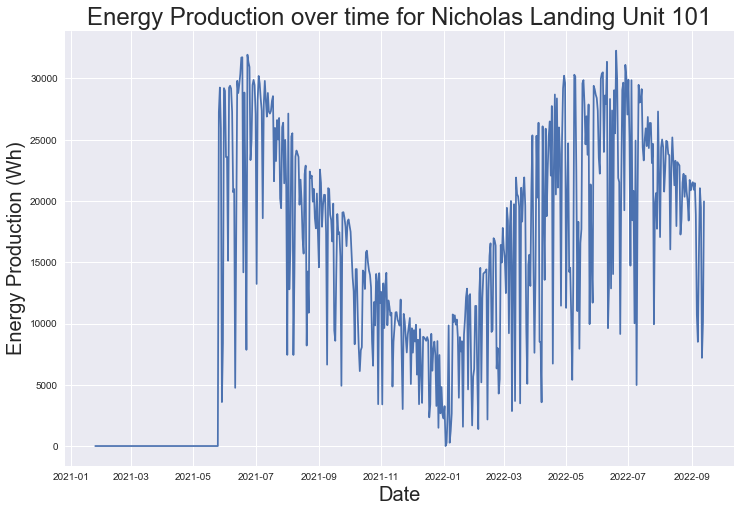

In [11]:
fig,ax = plt.subplots(figsize = (12,8))
x = df.date
y = df.enwh
y_mean = [np.mean(y)]*len(x)

# Plot the data
data_line = ax.plot(x, y)
               
    
# Make a legend
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Energy Production (Wh)', fontsize = 20)
plt.title(f'Energy Production over time for {systemName}', fontsize = 24)
plt.show()

# Energy Consumption

## Grab energy consumption using the consumption_lifetime call

In [67]:
# Grabbing lifetime energy from meters (and micros before meters were installed). 
# Daily from start of system to yesterday
url_old = url_base_old + 'systems/%s/consumption_lifetime' % systemId
url = url_base + 'systems/%s/consumption_lifetime' % systemId
df_sets = []
days_sets = []
params = {'user_id': userId,
          'key': key_old,
          'datetime_format': 'iso8601'}

r = requests.get(url=url_old, params=params)

startTime = r.json()['start_date']
print(r.json()['meta']['status'])
df = pd.DataFrame.from_dict(r.json()['consumption'])
df.rename(columns = {0:'enwh'}, inplace = True)

#add appropriate dates to dataframe
t1 = datetime.strptime(startDate, '%Y-%m-%d')
date_holder = []
for i in range(len(df)):
    date_holder.append(t1)
    t1 +=  timedelta(days = 1)
df['date'] = date_holder

normal


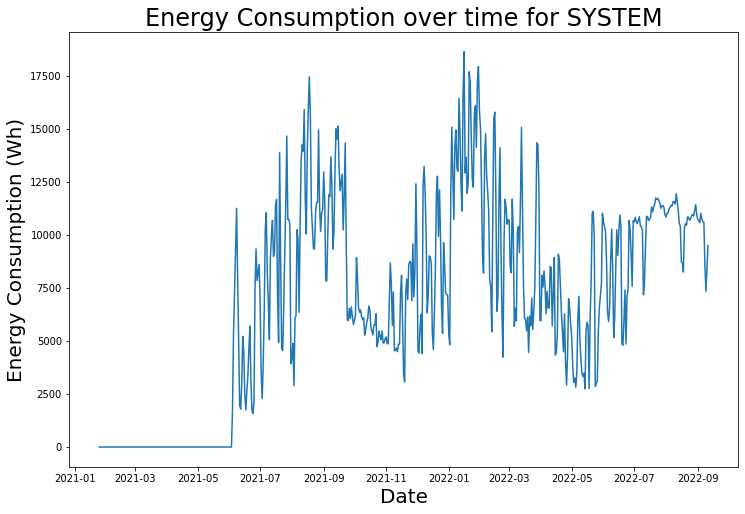

In [69]:
fig,ax = plt.subplots(figsize = (12,8))
x = df.date
y = df.enwh
y_mean = [np.mean(y)]*len(x)

# Plot the data
data_line = ax.plot(x, y)
               
    
# Make a legend
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Energy Consumption (Wh)', fontsize = 20)
plt.title('Energy Consumption over time for SYSTEM', fontsize = 24)
plt.show()

# Production vs Consumption Building 1

## Grabbing locations in location_holder1

In [152]:
#put in either the location id as an integer or the name as a string
location_holder1 = {}
locations1 = ['Nicholas Landing Unit 101', 'Nicholas Landing Unit 102', 'Nicholas Landing Unit 103',
              'Nicholas Landing Unit 104', 'Nicholas Landing Unit 105']
for location in locations1:
    if location.isdigit() == False:
        systemName = system_list_xcl[system_list_xcl['system_name'] == location]['system_name'].values[0]
        systemId = system_list_xcl[system_list_xcl['system_name'] == location]['system_id'].values[0]
    elif location.isdigit() == True:
        location = int(location)
        systemName = system_list_xcl[system_list_xcl['system_id'] == location]['system_name'].values[0]
        systemId = system_list_xcl[system_list_xcl['system_id'] == location]['system_id'].values[0]
    location_holder1[systemName] = str(systemId)
    print(f' System name: {systemName}. \n System ID: {systemId}')

 System name: Nicholas Landing Unit 101. 
 System ID: 2089504
 System name: Nicholas Landing Unit 102. 
 System ID: 2089508
 System name: Nicholas Landing Unit 103. 
 System ID: 2089514
 System name: Nicholas Landing Unit 104. 
 System ID: 2089518
 System name: Nicholas Landing Unit 105. 
 System ID: 2089525


## Grabbing production in **dfs_prod**

In [292]:
# Grabbing lifetime energy from meters (and micros before meters were installed). 
# Daily from start of system to yesterday
dfs_prod = {}
for location in location_holder1:
    systemName = location
    systemId = location_holder1[location]
    url_old = url_base_old + 'systems/%s/energy_lifetime' % systemId
    params = {'user_id': userId,
              'key': key_old,
              'datetime_format': 'iso8601'}

    r = requests.get(url=url_old, params=params)

    startTime = r.json()['start_date']
    print(r.json()['meta']['status'])
    df_prod = pd.DataFrame.from_dict(r.json()['production'])
    df_prod.rename(columns = {0:'enwh'}, inplace = True)

    #add appropriate dates to dataframe
    t1 = datetime.strptime(startTime.split('T')[0], '%Y-%m-%d')
    date_holder = []
    for i in range(len(df_prod)):
        date_holder.append(t1)
        t1 +=  timedelta(days = 1)
    df_prod['date'] = date_holder
    df_prod['system_name'] = systemName
    df_prod['system_id'] = systemId
    dfs_prod[systemName] = df_prod
#pd.concat(dfs_prod)

normal
normal
normal
normal
normal


## Grabbing consumption in **dfs_cons**

In [291]:
# Grabbing lifetime energy from meters (and micros before meters were installed). 
# Daily from start of system to yesterday
dfs_cons = {}
for location in location_holder1:
    systemName = location
    systemId = location_holder1[location]
    url_old = url_base_old + 'systems/%s/consumption_lifetime' % systemId
    url = url_base + 'systems/%s/consumption_lifetime' % systemId
    params = {'user_id': userId,
              'key': key_old,
              'datetime_format': 'iso8601'}

    r = requests.get(url=url_old, params=params)

    startTime = r.json()['start_date']
    print(r.json()['meta']['status'])
    df_cons = pd.DataFrame.from_dict(r.json()['consumption'])
    df_cons.rename(columns = {0:'enwh'}, inplace = True)

    #add appropriate dates to dataframe
    t1 = datetime.strptime(startTime.split('T')[0], '%Y-%m-%d')
    date_holder = []
    for i in range(len(df_cons)):
        date_holder.append(t1)
        t1 +=  timedelta(days = 1)
    df_cons['date'] = date_holder
    df_cons['system_name'] = systemName
    df_cons['system_id'] = systemId
    dfs_cons[systemName] = df_cons
    #pd.concat(dfs_prod)

normal
normal
normal
normal
normal


## Set the dates to start the production and consumption data for building 1 to avoid the 0 periods

In [293]:
cut_off_dates_prod1 = {'Nicholas Landing Unit 101': 121,
                'Nicholas Landing Unit 102': 0,
                'Nicholas Landing Unit 103': 0,
                'Nicholas Landing Unit 104': 0,
                'Nicholas Landing Unit 105': 0}
cut_off_dates_cons1 = {'Nicholas Landing Unit 101': 130,
                'Nicholas Landing Unit 102': 141,
                'Nicholas Landing Unit 103': 141,
                'Nicholas Landing Unit 104': 141,
                'Nicholas Landing Unit 105': 141}

## Cut off the data with the 0's

In [294]:
#Save a copy
dfs_prod_backup = dfs_prod.copy()
dfs_cons_backup = dfs_cons.copy()

In [295]:
#Reset to copy
dfs_prod = dfs_prod_backup.copy()
dfs_cons = dfs_cons_backup.copy()

In [296]:
for i in dfs_prod: #list of locations
    dfs_prod[i] = dfs_prod[i][cut_off_dates_prod1[i]:]
    dfs_cons[i] = dfs_cons[i][cut_off_dates_cons1[i]:]
    
    dfs_prod[i].reset_index(inplace = True, drop = True)
    dfs_cons[i].reset_index(inplace = True, drop = True)

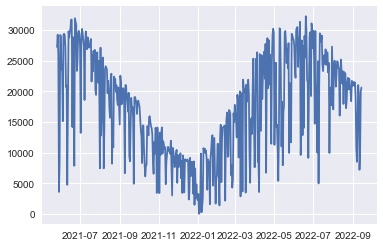

In [214]:
#plt.plot(dfs_prod['Nicholas Landing Unit 101'].date, dfs_prod['Nicholas Landing Unit 101'].enwh)

## Group the **dfs_prod**, **dfs_cons** by month

In [297]:
#ignore warning codes
pd.options.mode.chained_assignment = None #None, warn, raise

In [298]:
#save months, years for dfs_prod
for i in dfs_prod: #list of locations
    for j in range(len(dfs_prod[i])):
        month = str(dfs_prod[i]['date'][j].month)
        year = str(dfs_prod[i]['date'][j].year)
        
        dfs_prod[i].loc[j, 'month'] = month
        dfs_prod[i].loc[j, 'year'] = year

In [299]:
#save months, years for dfs_cons
for i in dfs_cons: #list of locations
    for j in range(len(dfs_cons[i])):
        month = str(dfs_cons[i]['date'][j].month)
        year = str(dfs_cons[i]['date'][j].year)
        
        dfs_cons[i].loc[j, 'month'] = month
        dfs_cons[i].loc[j, 'year'] = year

In [300]:
#production
dfs_prod_month = dfs_prod.copy()
for i in dfs_prod:
    sys_name = dfs_prod[i]['system_name'][0]
    sys_id = dfs_prod[i]['system_id'][0]
    
    #group by month
    dfs_prod_month[i] = dfs_prod[i].groupby(by = ['year', 'month']).sum().reset_index()
    
    #save dates in 'date' column
    dfs_prod_month[i]['date'] = pd.to_datetime(dfs_prod_month[i]['month'] + '-' + dfs_prod_month[i]['year'])
    dfs_prod_month[i].sort_values(by = 'date', inplace = True)
    
    #restore the system name and id
    dfs_prod_month[i]['system_name'] = sys_name
    dfs_prod_month[i]['system_id'] = sys_id
    
    

In [301]:
#consumption
dfs_cons_month = dfs_cons.copy()
for i in dfs_cons:
    sys_name = dfs_cons[i]['system_name'][0]
    sys_id = dfs_cons[i]['system_id'][0]
    
    #group by month
    dfs_cons_month[i] = dfs_cons[i].groupby(by = ['year', 'month']).sum().reset_index()
    
    #save dates in 'date' column
    dfs_cons_month[i]['date'] = pd.to_datetime(dfs_cons_month[i]['month'] + '-' + dfs_cons_month[i]['year'])
    dfs_cons_month[i].sort_values(by = 'date', inplace = True)
    
    #restore the system name and id
    dfs_cons_month[i]['system_name'] = sys_name
    dfs_cons_month[i]['system_id'] = sys_id

In [302]:
#save daily values
dfs_prod_daily = dfs_prod.copy()
dfs_cons_daily = dfs_cons.copy()

In [303]:
#save the monthly data into dfs_prod
dfs_prod = dfs_prod_month
dfs_cons = dfs_cons_month

## Graphing Energy Productions separetely and together

In [ ]:
cons_merged['month'] = cons_merged['date'].dt.month
cons_merged['year'] = cons_merged['date'].dt.year

test = cons_merged.copy()
test['2021'] = np.zeros(len(test['date']))
test['2022'] = np.zeros(len(test['date']))

for i in range(len(test['date'])):
    for years in test.year.unique():
        if test['year'][i] == years: 
            test[str(years)][i] = test['enwh'][i]
test
data = test[['month', '2021', '2022']]

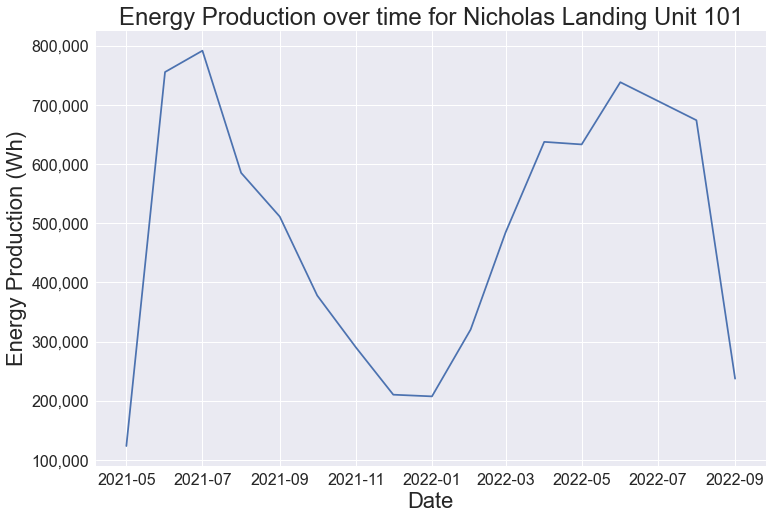

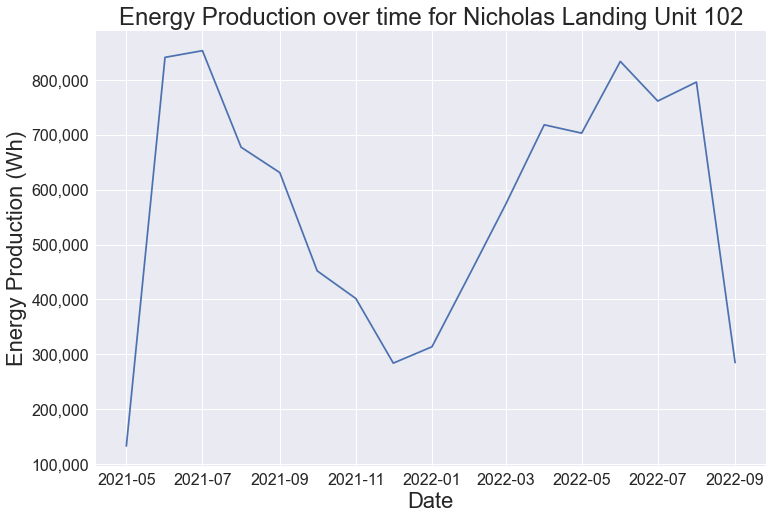

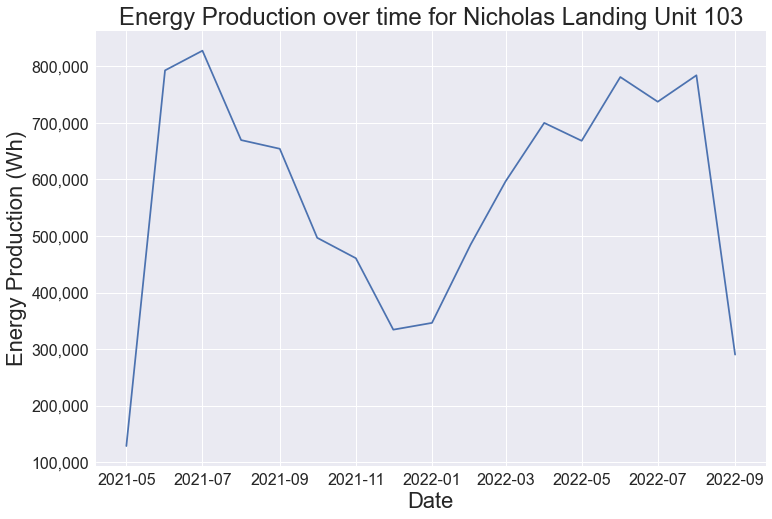

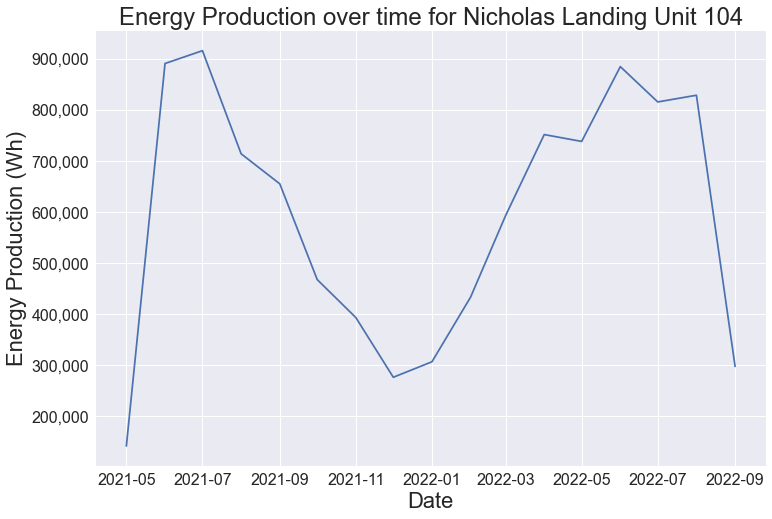

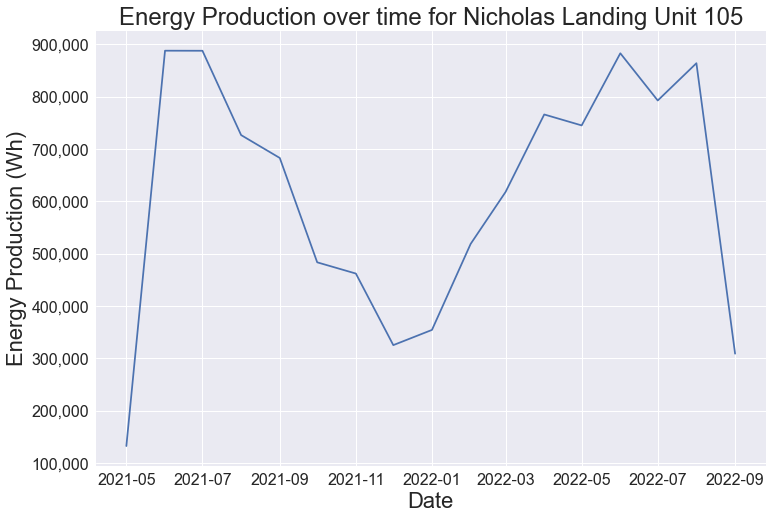

In [305]:
for system in dfs_prod:
    df = dfs_prod[system]
    
    fig,ax = plt.subplots(figsize = (12,8))
    x = df.date
    y = df.enwh
    y_mean = np.mean(y)

    # Plot the data
    data_line = ax.plot(x, y)
    
    #Plot the mean
    trans = ax.get_yaxis_transform()
    #ax.axhline(y_mean, color = 'orange', label = f'Mean: {y_mean.round(2)}')
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))


    # Make a legend
    plt.xlabel('Date')
    plt.ylabel('Energy Production (Wh)')
    plt.title(f'Energy Production over time for {system}')
    #plt.legend(loc = 'upper right', fontsize = 20)
    plt.savefig(f'nick_landing/{system}_production.png')
    plt.show()

## Graphing Energy Consumptions separetely and together

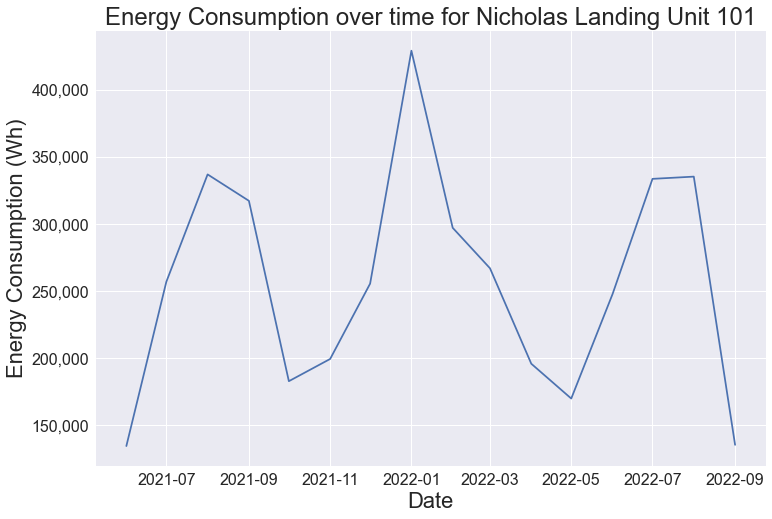

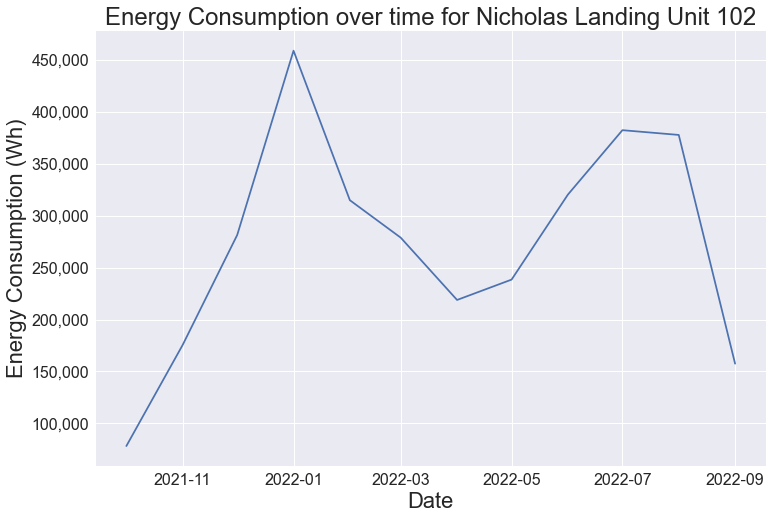

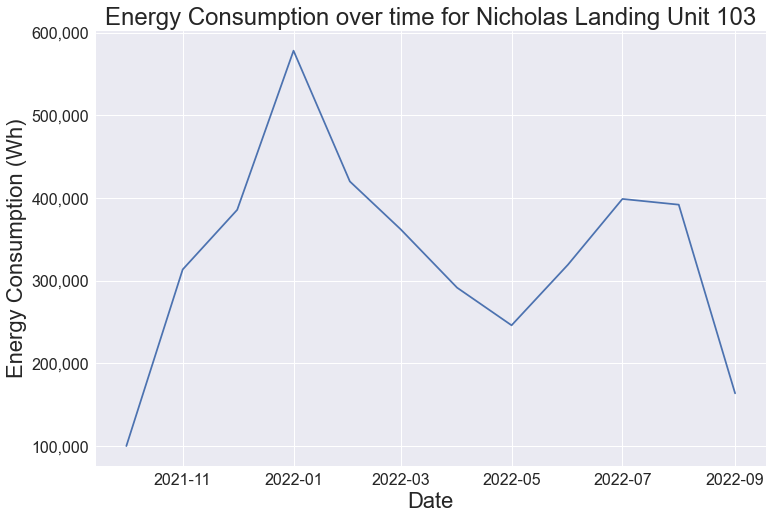

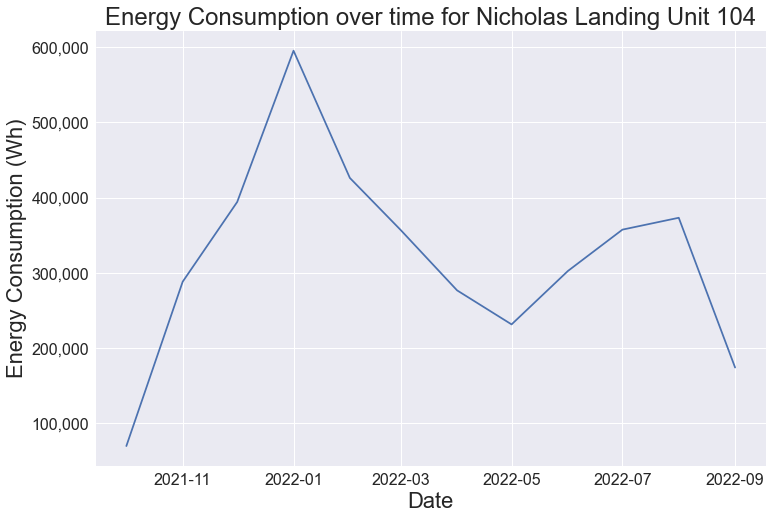

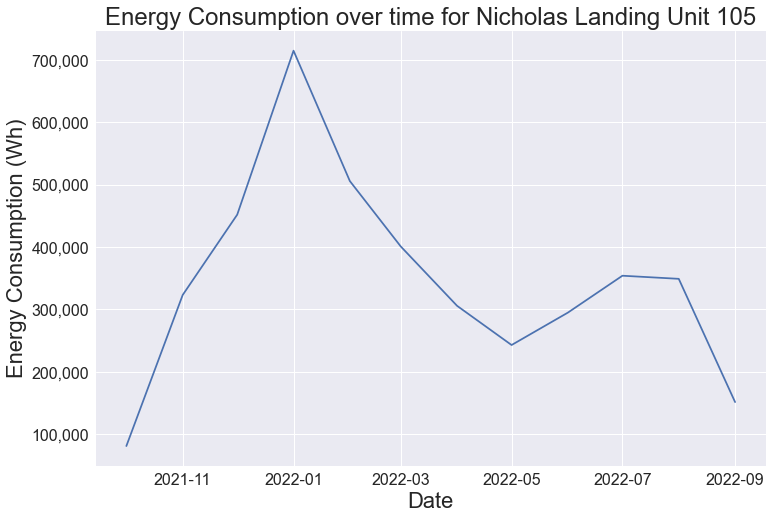

In [306]:
for system in dfs_cons:
    df = dfs_cons[system]
    
    fig,ax = plt.subplots(figsize = (12,8))
    x = df.date
    y = df.enwh
    y_mean = np.mean(y)

    # Plot the data
    data_line = ax.plot(x, y)
    
    #Plot the mean
    trans = ax.get_yaxis_transform()
    #ax.axhline(y_mean, color = 'orange', label = f'Mean: {y_mean.round(2)}')
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))


    # Make a legend
    plt.xlabel('Date')
    plt.ylabel('Energy Consumption (Wh)')
    plt.title(f'Energy Consumption over time for {system}')
    #plt.legend(loc = 'upper right', fontsize = 20)
    plt.savefig(f'nick_landing/{system}_consumption.png')
    plt.show()

## Graphing Energy Production vs Consumption

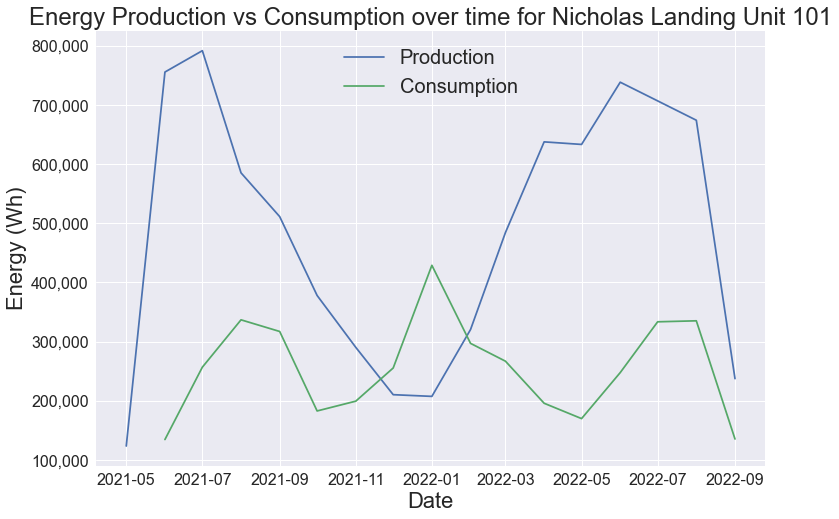

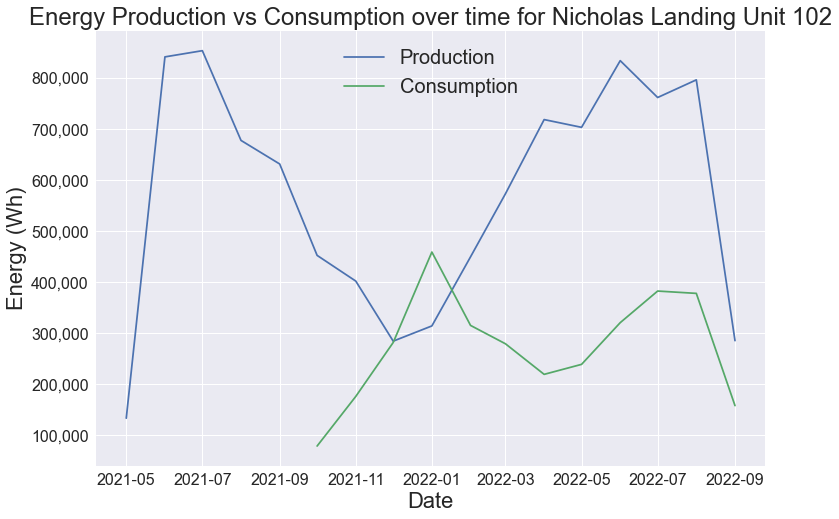

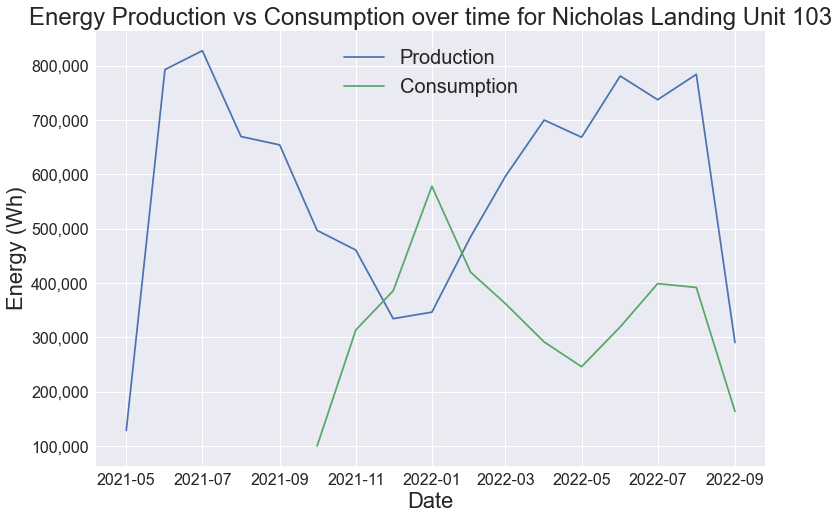

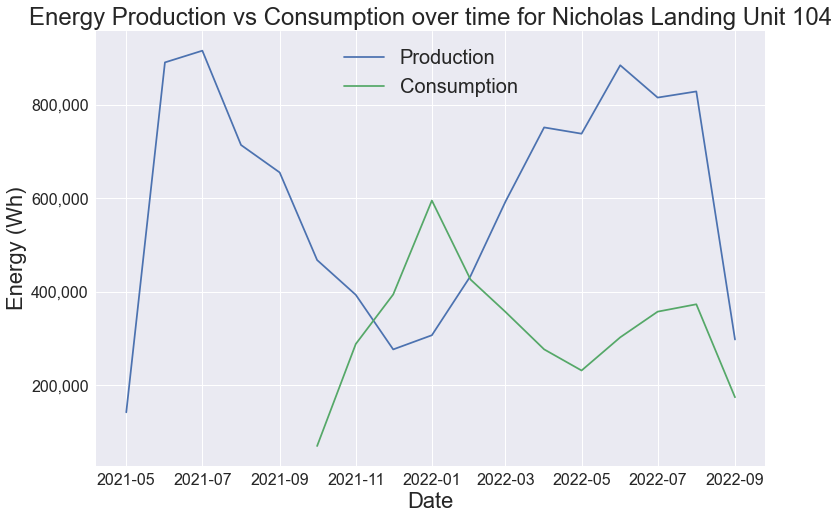

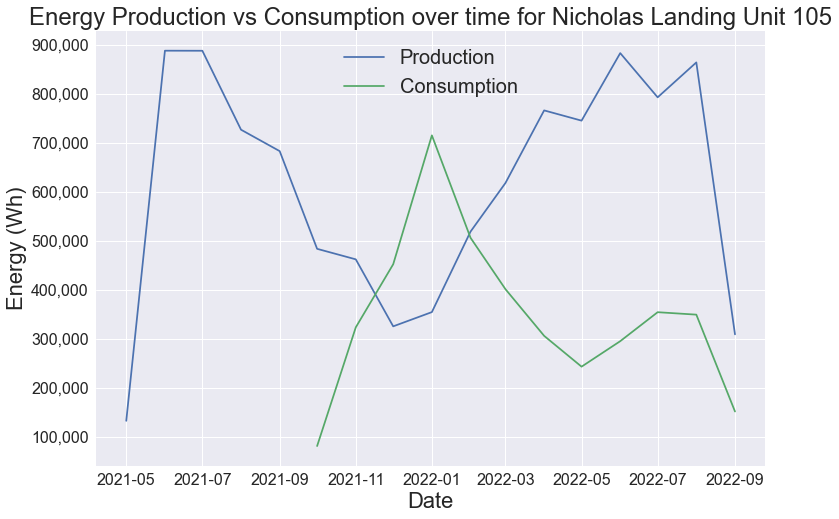

In [307]:
for (system_cons, system_prod) in zip(dfs_cons, dfs_prod):
    df_cons = dfs_cons[system_cons]
    df_prod = dfs_prod[system_prod]
    
    fig,ax = plt.subplots(figsize = (12,8))
    x_prod = df_prod.date
    y_prod = df_prod.enwh
    
    x_cons = df_cons.date
    y_cons = df_cons.enwh
    
    #y_diff = y_prod-y_cons

    # Plot the data
    data_line_prod = ax.plot(x_prod, y_prod, label = 'Production')
    data_line_cons = ax.plot(x_cons, y_cons, label = 'Consumption')
    #data_line_diff = ax.plot(x_prod, y_diff, color = 'green', label = 'Difference')
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

    # Make a legend
    plt.xlabel('Date')
    plt.ylabel('Energy (Wh)')
    plt.title(f'Energy Production vs Consumption over time for {system_cons}')
    plt.legend(loc = 'upper center')
    plt.savefig(f'nick_landing/{system_cons}_ProdvsCons.png')
    plt.show()

# Production vs Consumption Building 2

## Grabbing locations in location_holder2

In [308]:
#put in either the location id as an integer or the name as a string
location_holder2 = {}
locations2 = ['Nicholas Landing Unit 201', 'Nicholas Landing Unit 202', 'Nicholas Landing Unit 203',
              'Nicholas Landing Unit 204']
for location in locations2:
    if location.isdigit() == False:
        systemName = system_list_xcl[system_list_xcl['system_name'] == location]['system_name'].values[0]
        systemId = system_list_xcl[system_list_xcl['system_name'] == location]['system_id'].values[0]
    elif location.isdigit() == True:
        location = int(location)
        systemName = system_list_xcl[system_list_xcl['system_id'] == location]['system_name'].values[0]
        systemId = system_list_xcl[system_list_xcl['system_id'] == location]['system_id'].values[0]
    location_holder2[systemName] = systemId
    print(f' System name: {systemName}. \n System ID: {systemId}')

 System name: Nicholas Landing Unit 201. 
 System ID: 2089528
 System name: Nicholas Landing Unit 202. 
 System ID: 2089532
 System name: Nicholas Landing Unit 203. 
 System ID: 2089540
 System name: Nicholas Landing Unit 204. 
 System ID: 2089537


## Grabbing production in **dfs_prod2**

In [309]:
# Grabbing lifetime energy from meters (and micros before meters were installed). 
# Daily from start of system to yesterday
dfs_prod2 = {}
for location in location_holder2:
    systemName = location
    systemId = location_holder2[location]
    url_old = url_base_old + 'systems/%s/energy_lifetime' % systemId
    params = {'user_id': userId,
              'key': key_old,
              'datetime_format': 'iso8601'}

    r = requests.get(url=url_old, params=params)

    startTime = r.json()['start_date']
    print(r.json()['meta']['status'])
    df_prod = pd.DataFrame.from_dict(r.json()['production'])
    df_prod.rename(columns = {0:'enwh'}, inplace = True)

    #add appropriate dates to dataframe
    t1 = datetime.strptime(startTime.split('T')[0], '%Y-%m-%d')
    date_holder = []
    for i in range(len(df_prod)):
        date_holder.append(t1)
        t1 +=  timedelta(days = 1)
    df_prod['date'] = date_holder
    df_prod['system_name'] = systemName
    df_prod['system_id'] = systemId
    dfs_prod2[systemName] = df_prod
#pd.concat(dfs_prod)

normal
normal
normal
normal


In [ ]:
# dfs_prod_backup = dfs_prod.copy()
# dfs_cons_backup = dfs_cons.copy()
# for i in dfs_prod: #list of locations
#     dfs_prod[i] = dfs_prod[i][cut_off_dates_prod1[i]:]
#     dfs_cons[i] = dfs_cons[i][cut_off_dates_cons1[i]:]

## Grabbing consumption in **dfs_cons**

In [310]:
# Grabbing lifetime energy from meters (and micros before meters were installed). 
# Daily from start of system to yesterday
dfs_cons2 = {}
for location in location_holder2:
    systemName = location
    systemId = location_holder2[location]
    url_old = url_base_old + 'systems/%s/consumption_lifetime' % systemId
    url = url_base + 'systems/%s/consumption_lifetime' % systemId
    params = {'user_id': userId,
              'key': key_old,
              'datetime_format': 'iso8601'}

    r = requests.get(url=url_old, params=params)

    startTime = r.json()['start_date']
    print(r.json()['meta']['status'])
    df_cons = pd.DataFrame.from_dict(r.json()['consumption'])
    df_cons.rename(columns = {0:'enwh'}, inplace = True)

    #add appropriate dates to dataframe
    t1 = datetime.strptime(startTime.split('T')[0], '%Y-%m-%d')
    date_holder = []
    for i in range(len(df_cons)):
        date_holder.append(t1)
        t1 +=  timedelta(days = 1)
    df_cons['date'] = date_holder
    df_cons['system_name'] = systemName
    df_cons['system_id'] = systemId
    dfs_cons2[systemName] = df_cons
    #pd.concat(dfs_prod)

normal
normal
normal
normal


## Set the dates to start the production and consumption data for building 1 to avoid the 0 periods

In [311]:
cut_off_dates_prod2 = {'Nicholas Landing Unit 201': 132,
                'Nicholas Landing Unit 202': 0,
                'Nicholas Landing Unit 203': 261,
                'Nicholas Landing Unit 204': 129}
cut_off_dates_cons2 = {'Nicholas Landing Unit 201': 279,
                'Nicholas Landing Unit 202': 15,
                'Nicholas Landing Unit 203': 262,
                'Nicholas Landing Unit 204': 144}

## Cut off the data with the 0's

In [312]:
#Save a copy
dfs_prod2_backup = dfs_prod2.copy()
dfs_cons2_backup = dfs_cons2.copy()

In [270]:
#Reset to copy
dfs_prod2 = dfs_prod2_backup.copy()
dfs_cons2 = dfs_cons2_backup.copy()

In [313]:
for i in dfs_prod2: #list of locations
    dfs_prod2[i] = dfs_prod2[i][cut_off_dates_prod2[i]:]
    dfs_cons2[i] = dfs_cons2[i][cut_off_dates_cons2[i]:]
    
    dfs_prod2[i].reset_index(inplace = True, drop = True)
    dfs_cons2[i].reset_index(inplace = True, drop = True)

## Group the **dfs_prod**, **dfs_cons** by month

In [314]:
#save months, years for dfs_prod
for i in dfs_prod2: #list of locations
    for j in range(len(dfs_prod2[i])):
        month = str(dfs_prod2[i]['date'][j].month)
        year = str(dfs_prod2[i]['date'][j].year)
        
        dfs_prod2[i].loc[j, 'month'] = month
        dfs_prod2[i].loc[j, 'year'] = year

In [315]:
#save months, years for dfs_cons
for i in dfs_cons2: #list of locations
    for j in range(len(dfs_cons2[i])):
        month = str(dfs_cons2[i]['date'][j].month)
        year = str(dfs_cons2[i]['date'][j].year)
        
        dfs_cons2[i].loc[j, 'month'] = month
        dfs_cons2[i].loc[j, 'year'] = year

In [316]:
#production
dfs_prod_month2 = dfs_prod2.copy()
for i in dfs_prod2:
    sys_name = dfs_prod2[i]['system_name'][0]
    sys_id = dfs_prod2[i]['system_id'][0]
    
    #group by month
    dfs_prod_month2[i] = dfs_prod2[i].groupby(by = ['year', 'month']).sum().reset_index()
    
    #save dates in 'date' column
    dfs_prod_month2[i]['date'] = pd.to_datetime(dfs_prod_month2[i]['month'] + '-' + dfs_prod_month2[i]['year'])
    dfs_prod_month2[i].sort_values(by = 'date', inplace = True)
    
    #restore the system name and id
    dfs_prod_month2[i]['system_name'] = sys_name
    dfs_prod_month2[i]['system_id'] = sys_id
    
    

In [317]:
#consumption
dfs_cons_month2 = dfs_cons2.copy()
for i in dfs_cons2:
    sys_name = dfs_cons2[i]['system_name'][0]
    sys_id = dfs_cons2[i]['system_id'][0]
    
    #group by month
    dfs_cons_month2[i] = dfs_cons2[i].groupby(by = ['year', 'month']).sum().reset_index()
    
    #save dates in 'date' column
    dfs_cons_month2[i]['date'] = pd.to_datetime(dfs_cons_month2[i]['month'] + '-' + dfs_cons_month2[i]['year'])
    dfs_cons_month2[i].sort_values(by = 'date', inplace = True)
    
    #restore the system name and id
    dfs_cons_month2[i]['system_name'] = sys_name
    dfs_cons_month2[i]['system_id'] = sys_id

In [318]:
#save daily values
dfs_prod_daily2 = dfs_prod2.copy()
dfs_cons_daily2 = dfs_cons2.copy()

In [319]:
#save the monthly data into dfs_prod
dfs_prod2 = dfs_prod_month2
dfs_cons2 = dfs_cons_month2

## Graphing Energy Productions separetely and together

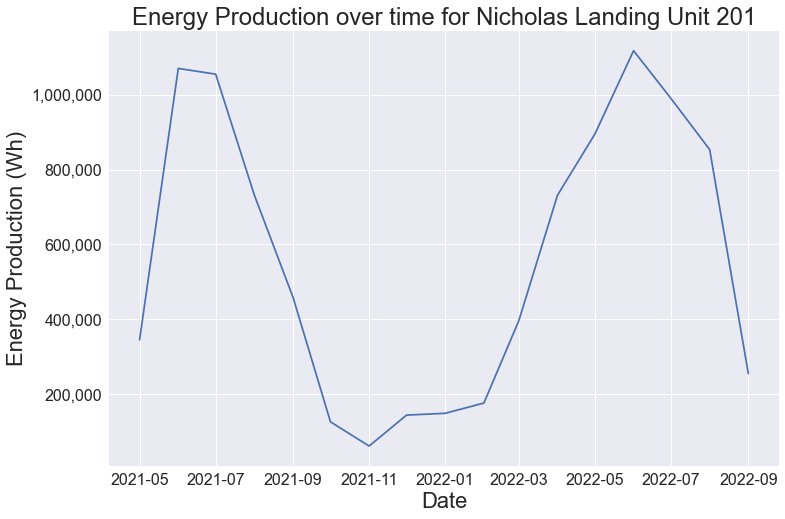

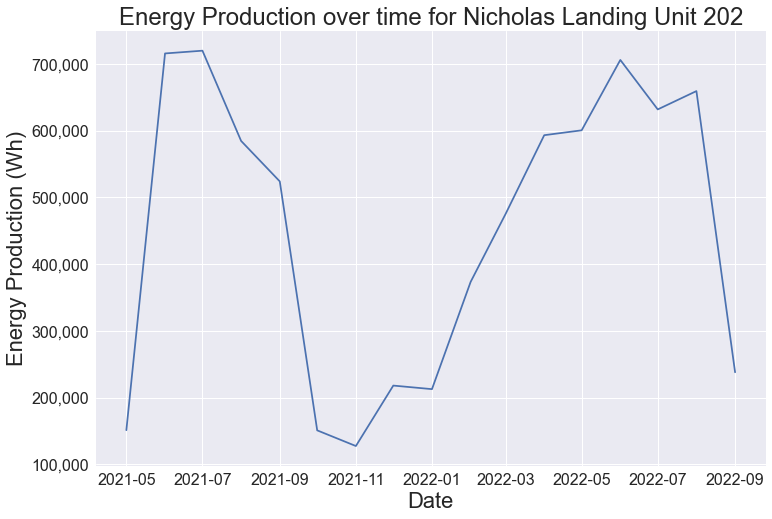

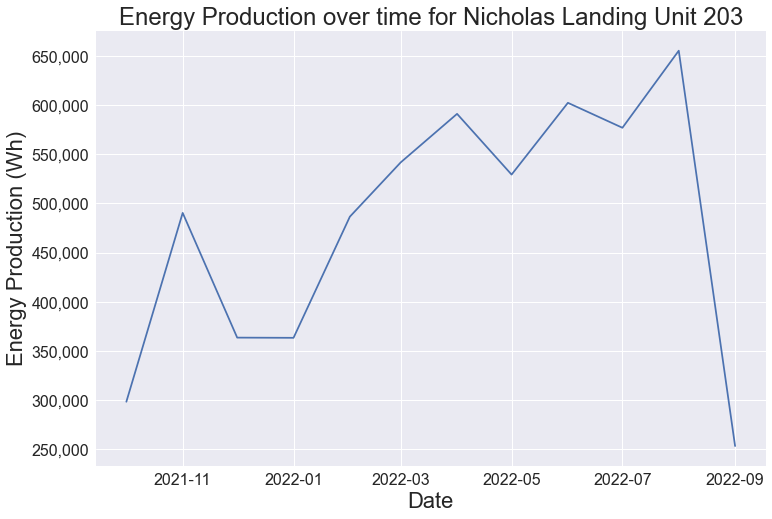

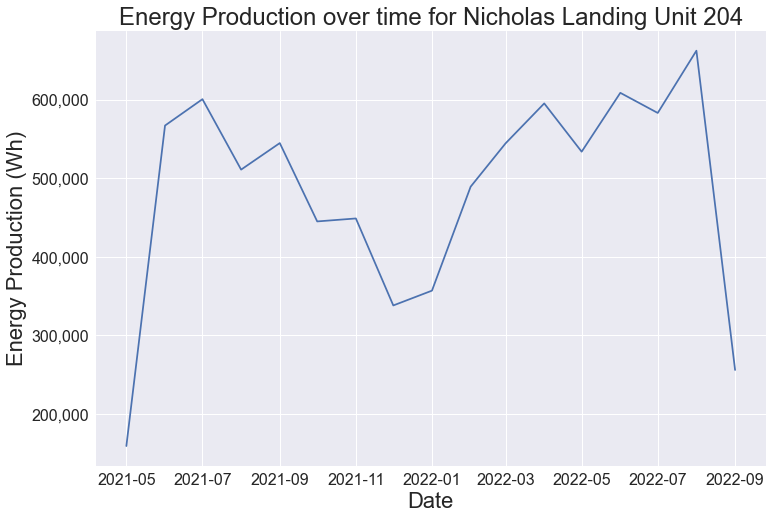

In [320]:
for system in dfs_prod2:
    df = dfs_prod2[system]
    
    fig,ax = plt.subplots(figsize = (12,8))
    x = df.date
    y = df.enwh
    y_mean = np.mean(y)

    # Plot the data
    data_line = ax.plot(x, y)
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    #Plot the mean
    trans = ax.get_yaxis_transform()
    #ax.axhline(y_mean, color = 'orange', label = f'Mean: {y_mean.round(2)}')

    # Make a legend
    plt.xlabel('Date')
    plt.ylabel('Energy Production (Wh)')
    plt.title(f'Energy Production over time for {system}')
    #plt.legend(loc = 'upper right')
    plt.savefig(f'nick_landing/{system}_consumption.png')
    plt.show()

## Graphing Energy Consumptions seperately and together

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


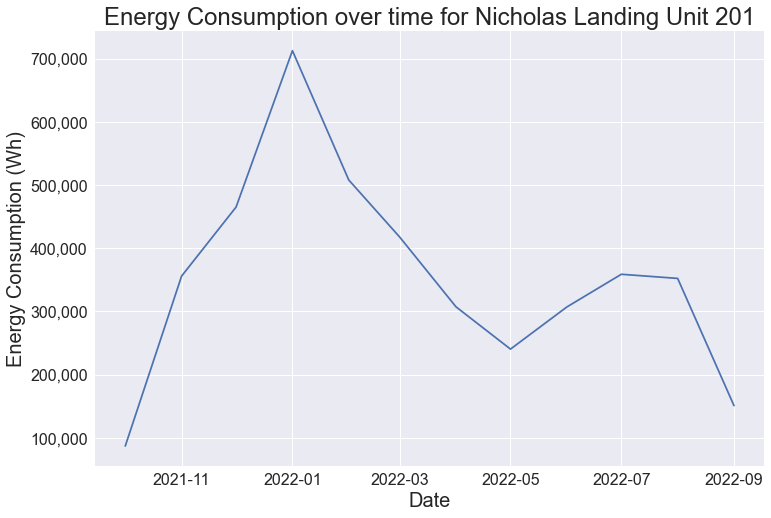

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


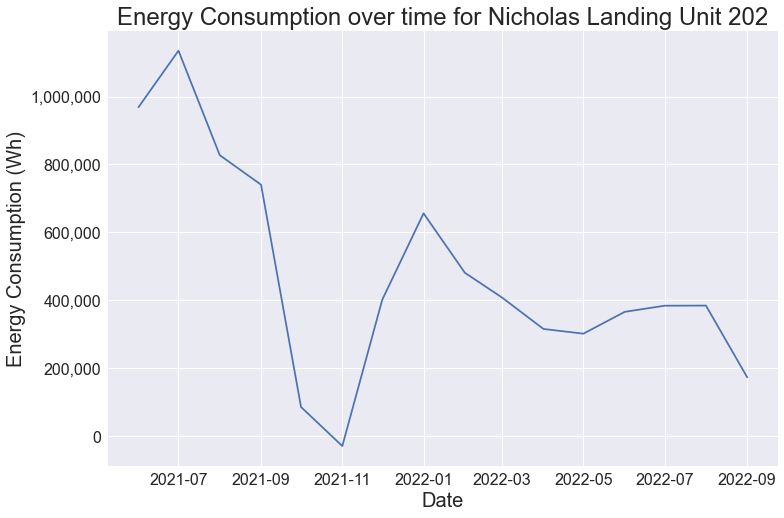

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


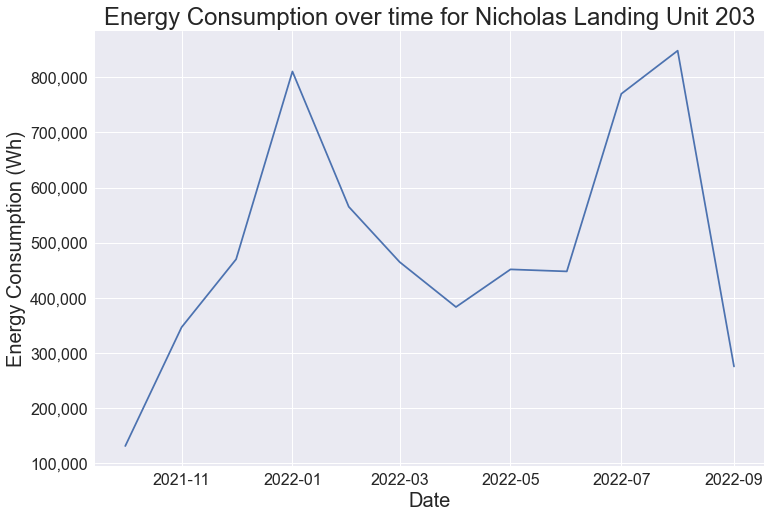

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


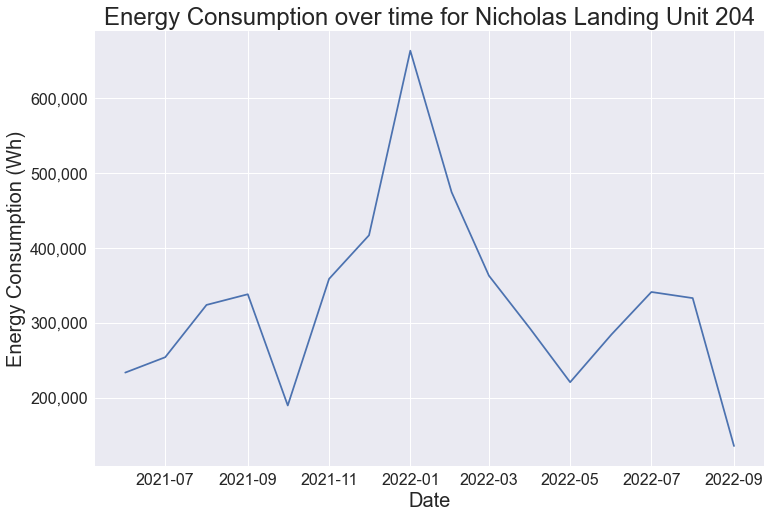

In [321]:
for system in dfs_cons2:
    df = dfs_cons2[system]
    
    fig,ax = plt.subplots(figsize = (12,8))
    x = df.date
    y = df.enwh
    y_mean = np.mean(y)

    # Plot the data
    data_line = ax.plot(x, y)
    
    #Plot the mean
    trans = ax.get_yaxis_transform()
    #ax.axhline(y_mean, color = 'orange', label = f'Mean: {y_mean.round(2)}')
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

    # Make a legend
    plt.xlabel('Date')
    plt.ylabel('Energy Consumption (Wh)')
    plt.title(f'Energy Consumption over time for {system}')
    #plt.legend(loc = 'upper right', fontsize = 20)
    plt.savefig(f'nick_landing/{system}_consumption.png')
    plt.show()

## Graphing Energy Production vs Consumption

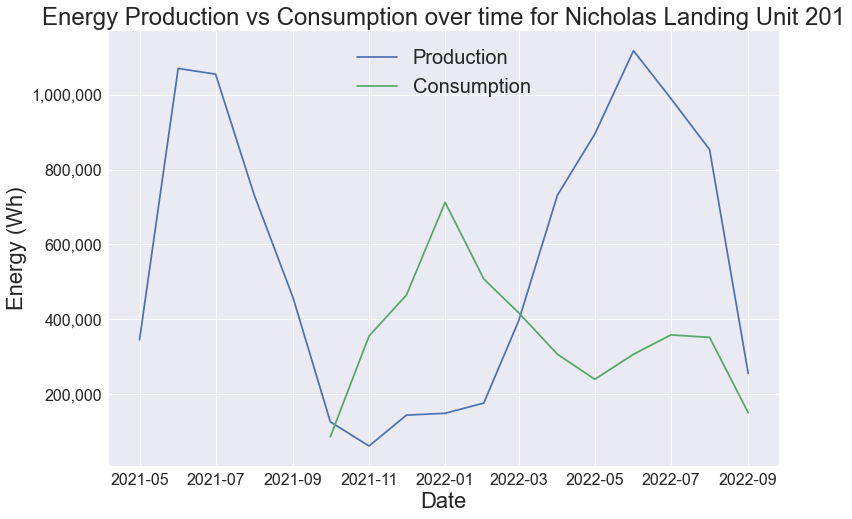

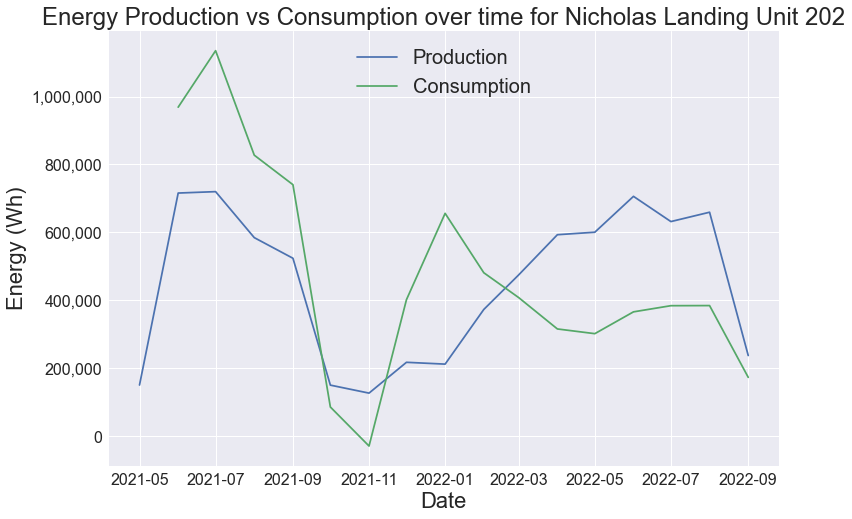

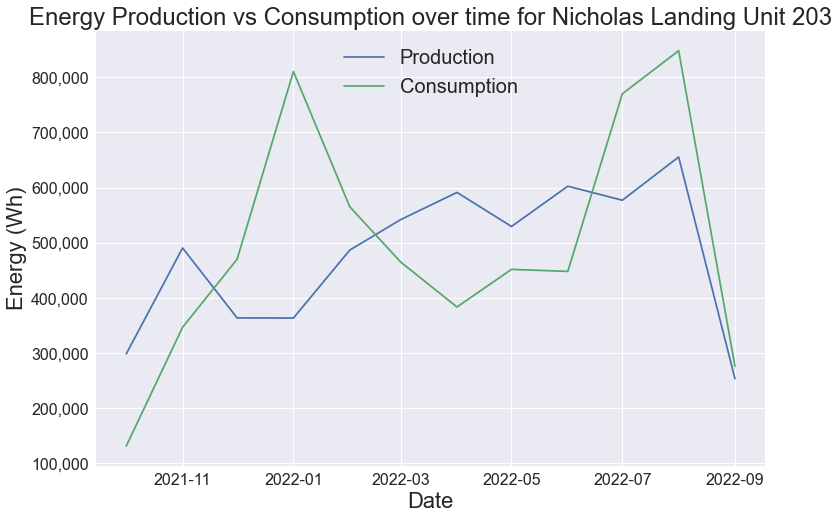

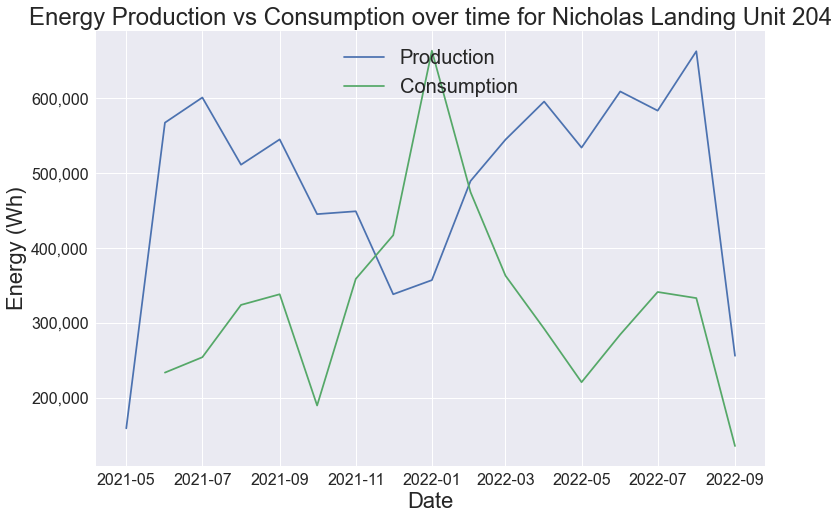

In [323]:

for (system_cons, system_prod) in zip(dfs_cons2, dfs_prod2):
    df_cons = dfs_cons2[system_cons]
    df_prod = dfs_prod2[system_prod]
    
    fig,ax = plt.subplots(figsize = (12,8))
    x_prod = df_prod.date
    y_prod = df_prod.enwh
    
    x_cons = df_cons.date
    y_cons = df_cons.enwh
    
    #y_diff = y_prod-y_cons

    # Plot the data
    data_line_prod = ax.plot(x_prod, y_prod, label = 'Production')
    data_line_cons = ax.plot(x_cons, y_cons, label = 'Consumption')
    #data_line_diff = ax.plot(x_prod, y_diff, color = 'green', label = 'Difference')
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

    # Make a legend
    plt.xlabel('Date')
    plt.ylabel('Energy (Wh)')
    plt.title(f'Energy Production vs Consumption over time for {system_cons}')
    plt.legend(loc = 'upper center')
    plt.savefig(f'nick_landing/{system_cons}_ProdvsCons.png')
    plt.show()

# Location 1 and Location 2 combined

## Combined the productions into **prod_merged**

In [324]:
x1 = pd.concat(dfs_prod)
x2 = pd.concat(dfs_prod2)
x1['system_id'] = x1['system_id'].astype(str)
x2['system_id'] = x2['system_id'].astype(str)

prod_merged = pd.merge(x1.groupby('date').sum(), x2.groupby('date').sum(), how = 'outer', on = 'date')
prod_merged['enwh_x'] = prod_merged['enwh_x'] .fillna(0)
prod_merged['enwh_y'] = prod_merged['enwh_y'] .fillna(0)
prod_merged['enwh'] = prod_merged['enwh_x'] + prod_merged['enwh_y']
prod_merged.reset_index(inplace = True, drop = False)
prod_merged.sort_values(by = 'date', inplace = True)
prod_merged.reset_index(inplace = True, drop = True)
prod_merged.head()

,date,enwh_x,enwh_y,enwh
0,2021-05-01,659496,656045,1315541
1,2021-06-01,4167986,2352803,6520789
2,2021-07-01,4276023,2375204,6651227
3,2021-08-01,3372708,1827462,5200170
4,2021-09-01,3134670,1528050,4662720


## Graphing Energy Productions

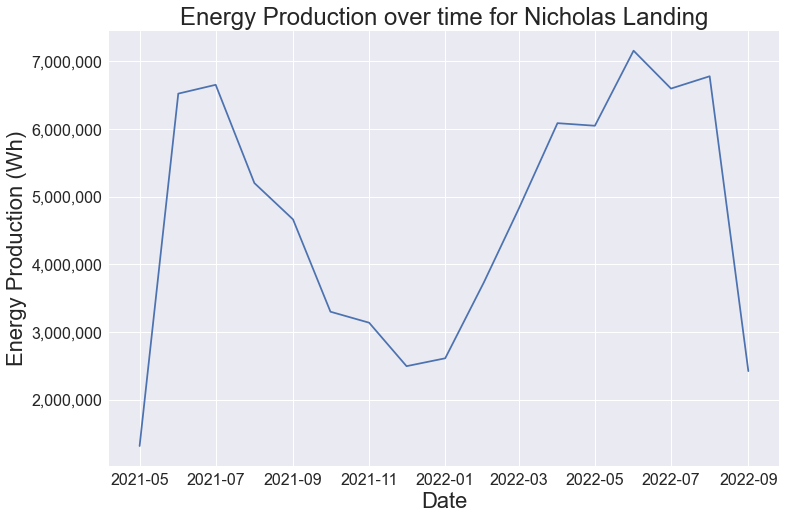

In [325]:
fig,ax = plt.subplots(figsize = (12,8))
x = prod_merged.date
y = prod_merged.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y)

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'orange', label = f'Mean: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy Production (Wh)')
plt.title(f'Energy Production over time for Nicholas Landing')
#plt.legend(loc = 'upper right', fontsize = 20)
plt.savefig('nick_landing/NicholasLanding_combined_production.png')
plt.show()

In [ ]:
#mean not relevant
#monthly total
#due it monthly, with years overlayed
#cue off tails, start when neither has 0's
#start after nubs
#recreate in excel

## Combined the productions into **prod_merged**

In [326]:
x1 = pd.concat(dfs_cons)
x2 = pd.concat(dfs_cons2)
x1['system_id'] = x1['system_id'].astype(str)
x2['system_id'] = x2['system_id'].astype(str)

cons_merged = pd.merge(x1.groupby('date').sum(), x2.groupby('date').sum(), how = 'outer', on = 'date')
cons_merged['enwh_x'] = cons_merged['enwh_x'] .fillna(0)
cons_merged['enwh_y'] = cons_merged['enwh_y'] .fillna(0)
cons_merged['enwh'] = cons_merged['enwh_x'] + cons_merged['enwh_y']
cons_merged.reset_index(inplace = True, drop = False)
cons_merged.sort_values(by = 'date', inplace = True)
cons_merged.reset_index(inplace = True, drop = True)
cons_merged.head()

,date,enwh_x,enwh_y,enwh
0,2021-06-01,134577,1202139,1336716
1,2021-07-01,256821,1388861,1645682
2,2021-08-01,336820,1151279,1488099
3,2021-09-01,317153,1078682,1395835
4,2021-10-01,511883,494714,1006597


## Graphing Energy Consumptions

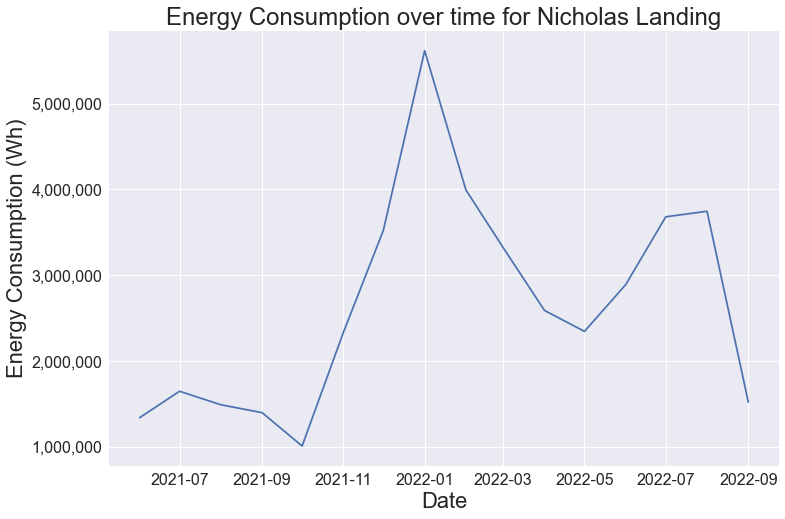

In [327]:
fig,ax = plt.subplots(figsize = (12,8))
x = cons_merged.date
y = cons_merged.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y)

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'orange', label = f'Mean: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy Consumption (Wh)')
plt.title(f'Energy Consumption over time for Nicholas Landing')
#plt.legend(loc = 'upper right', fontsize = 20)
plt.savefig('nick_landing/NicholasLanding_combined_consumption.png')
plt.show()

# Building 1 and 2 separate

## Production for building 1 in **build1_prod**, consumption for building 1 in **build1_cons** ...

In [328]:
build1_prod = pd.concat(dfs_prod)
build2_prod = pd.concat(dfs_prod2)

build1_prod['system_id'] = build1_prod['system_id'].astype(str)
build2_prod['system_id'] = build2_prod['system_id'].astype(str)

build1_prod = build1_prod.groupby(by = 'date').sum()
build1_prod.reset_index(inplace = True, drop = False)
build2_prod = build2_prod.groupby(by = 'date').sum()
build2_prod.reset_index(inplace = True, drop = False)

In [329]:
build1_cons = pd.concat(dfs_cons)
build2_cons = pd.concat(dfs_cons2)

build1_cons['system_id'] = build1_cons['system_id'].astype(str)
build2_cons['system_id'] = build2_cons['system_id'].astype(str)

build1_cons = build1_cons.groupby(by = 'date').sum()
build1_cons.reset_index(inplace = True, drop = False)
build2_cons = build2_cons.groupby(by = 'date').sum()
build2_cons.reset_index(inplace = True, drop = False)

## Graphing Production for building 1

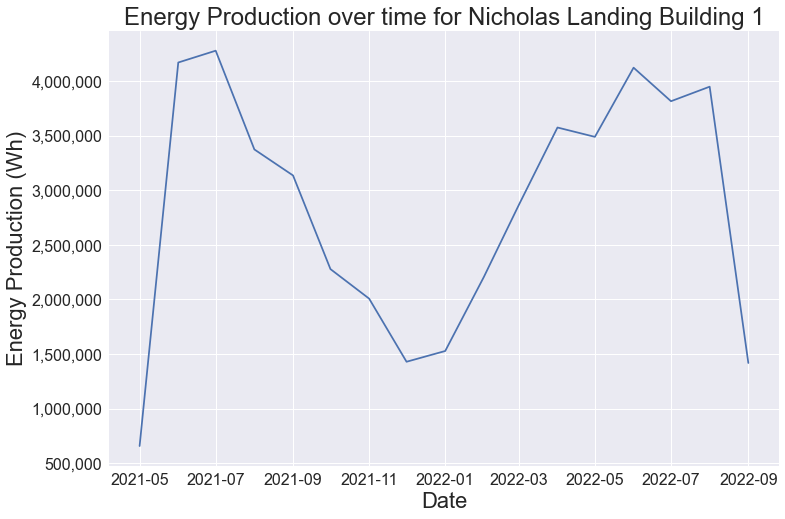

In [330]:
fig,ax = plt.subplots(figsize = (12,8))
x = build1_prod.date
y = build1_prod.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y)

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'orange', label = f'Average: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy Production (Wh)')
plt.title(f'Energy Production over time for Nicholas Landing Building 1')
#plt.legend(loc = 'upper right', fontsize = 20)
#plt.savefig('nick_landing/NicholasLanding_combined_consumption.png')
plt.show()

## Graphing Production for Building 2

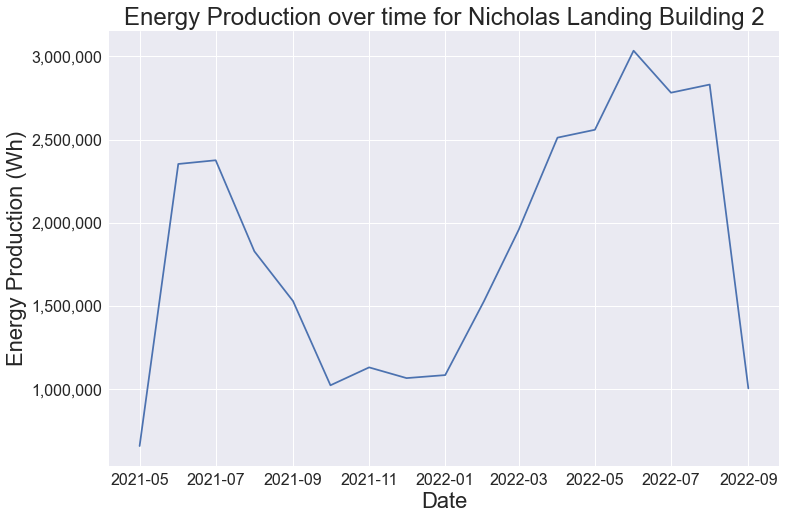

In [331]:
fig,ax = plt.subplots(figsize = (12,8))
x = build2_prod.date
y = build2_prod.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y)

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'orange', label = f'Average: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy Production (Wh)')
plt.title(f'Energy Production over time for Nicholas Landing Building 2')
#plt.legend(loc = 'upper right', fontsize = 20)
#plt.savefig('nick_landing/NicholasLanding_combined_consumption.png')
plt.show()

## Graphing Production Building 1 vs Building 2

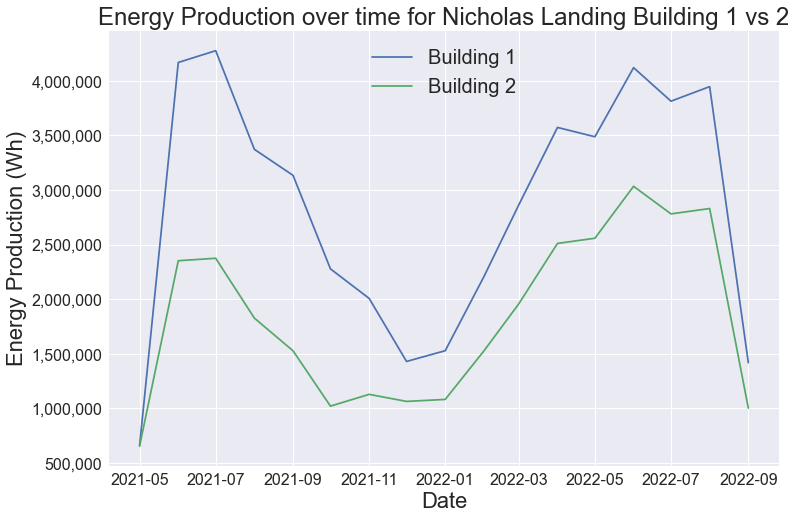

In [333]:
fig,ax = plt.subplots(figsize = (12,8))
#Building 1
x = build1_prod.date
y = build1_prod.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y, label = 'Building 1')

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'blue', label = f'Average Building 1: {y_mean.round(2)}')

#Building 2
x = build2_prod.date
y = build2_prod.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y, label = 'Building 2')

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'green', label = f'Average Building 2: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy Production (Wh)')
plt.title(f'Energy Production over time for Nicholas Landing Building 1 vs 2')
plt.legend(loc = 'upper center')
#plt.savefig('nick_landing/NicholasLanding_combined_consumption.png')
plt.show()

## Graphing Consumption for building 1

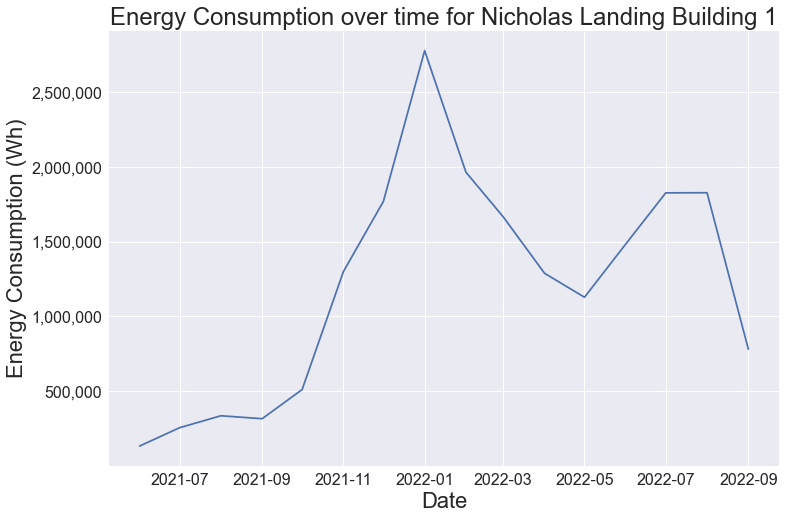

In [334]:
fig,ax = plt.subplots(figsize = (12,8))
x = build1_cons.date
y = build1_cons.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y)

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'orange', label = f'Average: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy Consumption (Wh)')
plt.title(f'Energy Consumption over time for Nicholas Landing Building 1')
#plt.legend(loc = 'upper right', fontsize = 20)
#plt.savefig('nick_landing/NicholasLanding_combined_consumption.png')
plt.show()

## Graphing Consumption for Building 2

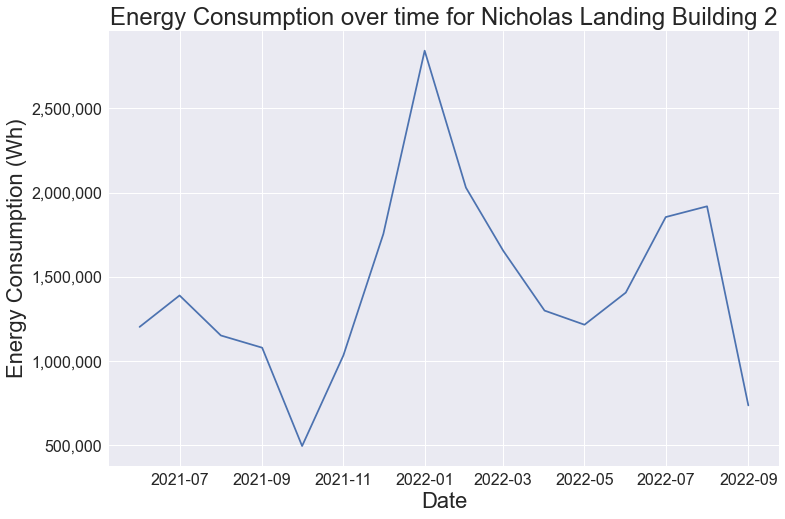

In [335]:
fig,ax = plt.subplots(figsize = (12,8))
x = build2_cons.date
y = build2_cons.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y)

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'orange', label = f'Average: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy Consumption (Wh)')
plt.title(f'Energy Consumption over time for Nicholas Landing Building 2')
#plt.legend(loc = 'upper right', fontsize = 20)
#plt.savefig('nick_landing/NicholasLanding_combined_consumption.png')
plt.show()

## Graphing Consumption Building 1 vs Building 2

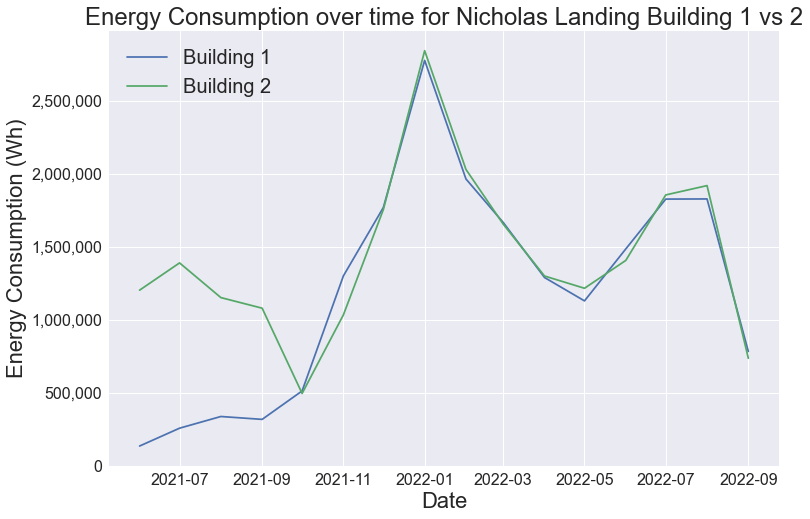

In [337]:
fig,ax = plt.subplots(figsize = (12,8))
#Building 1
x = build1_cons.date
y = build1_cons.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y, label = 'Building 1')

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'blue', label = f'Average Building 1: {y_mean.round(2)}')

#Building 2
x = build2_cons.date
y = build2_cons.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y, label = 'Building 2')

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'green', label = f'Average Building 2: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy Consumption (Wh)')
plt.title(f'Energy Consumption over time for Nicholas Landing Building 1 vs 2')
plt.legend(loc = 'upper left')
#plt.savefig('nick_landing/NicholasLanding_combined_consumption.png')
plt.show()

## Production vs Consumption Building 1

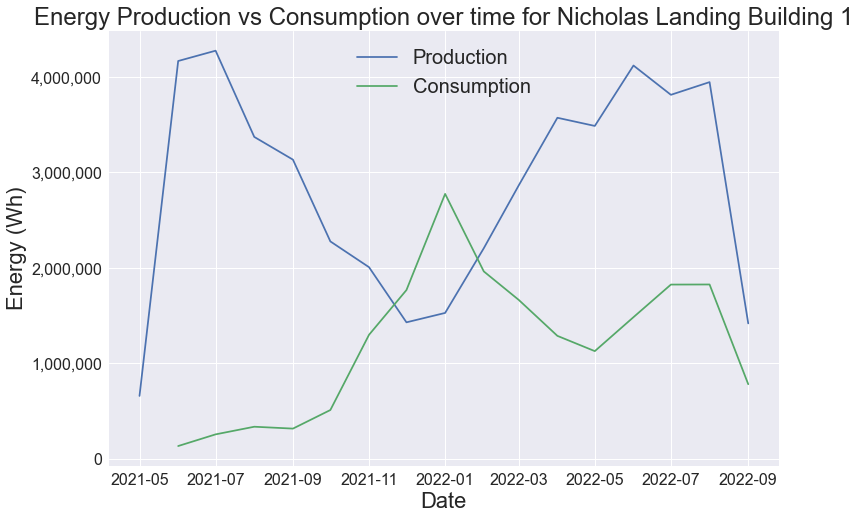

In [339]:
fig,ax = plt.subplots(figsize = (12,8))
#Building 1
x = build1_prod.date
y = build1_prod.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y, label = 'Production')

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'blue', label = f'Average Production: {y_mean.round(2)}')

#Building 2
x = build1_cons.date
y = build1_cons.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y, label = 'Consumption')

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'green', label = f'Average Consumption: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy (Wh)')
plt.title(f'Energy Production vs Consumption over time for Nicholas Landing Building 1')
plt.legend(loc = 'upper center')
#plt.savefig('nick_landing/NicholasLanding_combined_consumption.png')
plt.show()

## Production vs Consumption Building 2

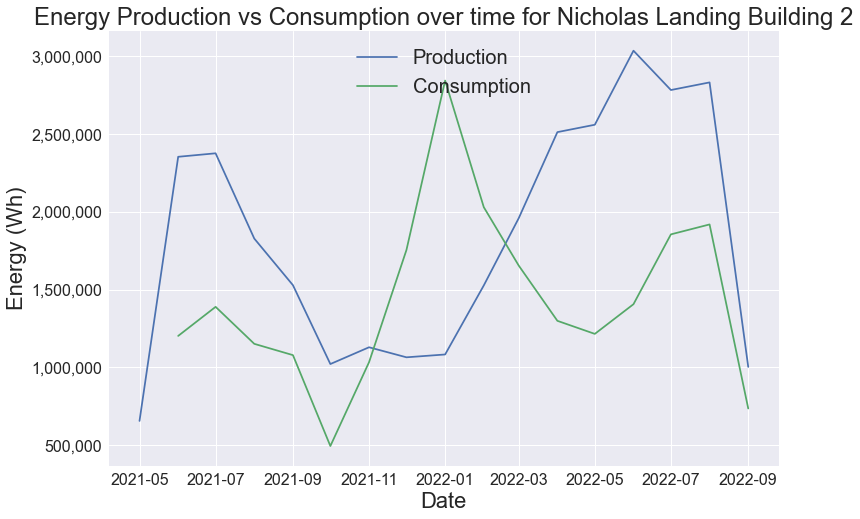

In [340]:
fig,ax = plt.subplots(figsize = (12,8))
#Building 1
x = build2_prod.date
y = build2_prod.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y, label = 'Production')

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'blue', label = f'Average Production: {y_mean.round(2)}')

#Building 2
x = build2_cons.date
y = build2_cons.enwh
y_mean = np.mean(y)

# Plot the data
data_line = ax.plot(x, y, label = 'Consumption')

#Plot the mean
trans = ax.get_yaxis_transform()
#ax.axhline(y_mean, color = 'green', label = f'Average Consumption: {y_mean.round(2)}')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Make a legend
plt.xlabel('Date')
plt.ylabel('Energy (Wh)')
plt.title(f'Energy Production vs Consumption over time for Nicholas Landing Building 2')
plt.legend(loc = 'upper center')
#plt.savefig('nick_landing/NicholasLanding_combined_consumption.png')
plt.show()

In [ ]:
#add the received excel chart to the report
#next year are these numbers - .6%

In [452]:
test

,date,enwh_x,enwh_y,enwh,month,year,2021,2022
0,2021-06-01,134577,1202139,1336716,6,2021,1336716.0,0.0
1,2021-07-01,256821,1388861,1645682,7,2021,1645682.0,0.0
2,2021-08-01,336820,1151279,1488099,8,2021,1488099.0,0.0
3,2021-09-01,317153,1078682,1395835,9,2021,1395835.0,0.0
4,2021-10-01,511883,494714,1006597,10,2021,1006597.0,0.0
5,2021-11-01,1299918,1033041,2332959,11,2021,2332959.0,0.0
6,2021-12-01,1768593,1754288,3522881,12,2021,3522881.0,0.0
7,2022-01-01,2775909,2842376,5618285,1,2022,0.0,5618285.0
8,2022-02-01,1963843,2029111,3992954,2,2022,0.0,3992954.0
9,2022-03-01,1665573,1654087,3319660,3,2022,0.0,3319660.0


In [453]:
excel_file = 'Test.xlsx'
sheet_name = 'Nicholas Landing'
data = test[['date', 'enwh']]
data.rename(columns = {'enwh':'Energy'})

#Set up writer
writer = pd.ExcelWriter(excel_file, engine='xlsxwriter', 
                        datetime_format='mmm yyyy',
                        date_format='mmmm-yyyy')
data.to_excel(writer, sheet_name=sheet_name, header = ['Date', 'Energy (wh)'])

# Access the XlsxWriter workbook and worksheet objects from the dataframe.
workbook = writer.book
worksheet = writer.sheets[sheet_name]

format1 = workbook.add_format({'num_format': '#,##0'})


# Set the column width and format.
worksheet.set_column(2, 2, 18, format1)
# Create a chart object.
chart = workbook.add_chart({'type': 'column', 'subtype':'stacked'})
# Get the number of rows and column index
max_row = len(data)
col_x = data.columns.get_loc('date') + 1
col_y = data.columns.get_loc('enwh') + 1

chart.add_series({
    'name':       "Total Energy",
    'categories': [sheet_name, 1, col_x, max_row, col_x],
    'values':     [sheet_name, 1, col_y, max_row, col_y],
    'marker':     {'type': 'circle', 'size': 4}
})

# Set name on axis
chart.set_x_axis({'name': 'Date'})
chart.set_y_axis({'name': 'Energy',
                  'major_gridlines': {'visible': False}})
# Insert the chart into the worksheet in field D2
worksheet.insert_chart('E2', chart, {'x_scale': 1.4, 'y_scale': 1.25})
# Close and save the Excel file
writer.save()

In [479]:
import calendar
data.sort_values(by = 'month', inplace = True)
data['month'] = data['month'].apply(lambda x: calendar.month_abbr[x])

In [483]:
df

,2021,2022
month,,
Apr,0.0,2587797.0
Aug,1488099.0,3745159.0
Dec,3522881.0,0.0
Feb,0.0,3992954.0
Jan,0.0,5618285.0
Jul,1645682.0,3680397.0
Jun,1336716.0,2890382.0
Mar,0.0,3319660.0
May,0.0,2343799.0


In [487]:
#WORKING STACKED BAR
import random
import pandas as pd


# Create a Pandas dataframe from the data.
#data.sort_values(by = 'month', inplace = True)
df = data.groupby(by = 'month').sum()
new_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 
             'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df = df.reindex(new_order, axis=0)
#df.set_index('month', inplace = True)

# Create a Pandas Excel writer using XlsxWriter as the engine.
excel_file = 'StackedBar.xlsx'
sheet_name = 'Nicholas Landing'


writer = pd.ExcelWriter(excel_file, engine='xlsxwriter', 
                        datetime_format='mmm yyyy',
                        date_format='mmmm-yyyy')
df.to_excel(writer, sheet_name=sheet_name)




writer = pd.ExcelWriter(excel_file, engine='xlsxwriter')
df.to_excel(writer, sheet_name=sheet_name)

# Access the XlsxWriter workbook and worksheet objects from the dataframe.
workbook = writer.book
worksheet = writer.sheets[sheet_name]

# Set the column width and format.
format1 = workbook.add_format({'num_format': '#,##0'})
worksheet.set_column(1, 2, 18, format1)

# Create a chart object.
chart = workbook.add_chart({'type': 'column', 'subtype': 'stacked'})

# Configure the series of the chart from the dataframe data.

max_row = len(df)
#col_x = data.columns.get_loc('date') + 1
#col_y = data.columns.get_loc('enwh') + 1

for col_num in range(1, len(df.columns) + 1):
    chart.add_series({
    'name':       [sheet_name, 0, col_num],
    'categories': [sheet_name, 1, 0, max_row, 0],
    'values':     [sheet_name, 1, col_num, max_row, col_num],
    'marker':     {'type': 'circle', 'size': 4}
    })
# Configure the chart axes.
chart.set_y_axis({'major_gridlines': {'visible': False}})

# Set name on axis
chart.set_x_axis({'name': 'Date'})
chart.set_y_axis({'name': 'Energy',
                  'major_gridlines': {'visible': True}})
chart.set_title({'name': 'Energy vs Time'})

worksheet.insert_chart('F2', chart, {'x_scale': 1.4, 'y_scale': 1.25})

# Close the Pandas Excel writer and output the Excel file.
writer.save()

In [489]:
#WORKING STACKED BAR
import random
import pandas as pd


# Create a Pandas dataframe from the data.
#data.sort_values(by = 'month', inplace = True)
df = data.groupby(by = 'month').sum()
new_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 
             'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df = df.reindex(new_order, axis=0)
#df.set_index('month', inplace = True)

# Create a Pandas Excel writer using XlsxWriter as the engine.
excel_file = 'StackedLine.xlsx'
sheet_name = 'Nicholas Landing'


writer = pd.ExcelWriter(excel_file, engine='xlsxwriter', 
                        datetime_format='mmm yyyy',
                        date_format='mmmm-yyyy')
df.to_excel(writer, sheet_name=sheet_name)




writer = pd.ExcelWriter(excel_file, engine='xlsxwriter')
df.to_excel(writer, sheet_name=sheet_name)

# Access the XlsxWriter workbook and worksheet objects from the dataframe.
workbook = writer.book
worksheet = writer.sheets[sheet_name]

# Set the column width and format.
format1 = workbook.add_format({'num_format': '#,##0'})
worksheet.set_column(1, 2, 18, format1)

# Create a chart object.
chart = workbook.add_chart({'type': 'line'})

# Configure the series of the chart from the dataframe data.

max_row = len(df)
#col_x = data.columns.get_loc('date') + 1
#col_y = data.columns.get_loc('enwh') + 1

for col_num in range(1, len(df.columns) + 1):
    chart.add_series({
    'name':       [sheet_name, 0, col_num],
    'categories': [sheet_name, 1, 0, max_row, 0],
    'values':     [sheet_name, 1, col_num, max_row, col_num],
    'marker':     {'type': 'circle', 'size': 4}
    })
# Configure the chart axes.
chart.set_y_axis({'major_gridlines': {'visible': False}})

# Set name on axis
chart.set_x_axis({'name': 'Date'})
chart.set_y_axis({'name': 'Energy',
                  'major_gridlines': {'visible': True}})
chart.set_title({'name': 'Energy vs Time'})

worksheet.insert_chart('F2', chart, {'x_scale': 1.4, 'y_scale': 1.25})

# Close the Pandas Excel writer and output the Excel file.
writer.save()

,date,enwh_x,enwh_y,enwh,month,year,2021,2022
0,2021-06-01,134577,1202139,1336716,6,2021,1336716.0,0.0
1,2021-07-01,256821,1388861,1645682,7,2021,1645682.0,0.0
2,2021-08-01,336820,1151279,1488099,8,2021,1488099.0,0.0
3,2021-09-01,317153,1078682,1395835,9,2021,1395835.0,0.0
4,2021-10-01,511883,494714,1006597,10,2021,1006597.0,0.0
5,2021-11-01,1299918,1033041,2332959,11,2021,2332959.0,0.0
6,2021-12-01,1768593,1754288,3522881,12,2021,3522881.0,0.0
7,2022-01-01,2775909,2842376,5618285,1,2022,0.0,5618285.0
8,2022-02-01,1963843,2029111,3992954,2,2022,0.0,3992954.0
9,2022-03-01,1665573,1654087,3319660,3,2022,0.0,3319660.0


In [476]:
data = test[['month', '2021', '2022']]